# Phase 1: Patient-Aware Data Splitting

This notebook creates reproducible train/validation/test splits from the locally extracted HAM10000 dataset. The split is lesion-aware, so the same lesion never appears in more than one split.

That constraint matters because random image-level splitting leaks patient information and inflates test performance.

In [5]:
from pathlib import Path
import json
import random

import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_root = project_root / "data"
raw_dir = data_root / "raw"
artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
split_dir = data_root / "splits"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
split_dir.mkdir(parents=True, exist_ok=True)

metadata_path = raw_dir / "HAM10000_metadata.csv"
if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

metadata_df = pd.read_csv(metadata_path)
metadata_df['label'] = (metadata_df['dx'] == 'mel').astype(int)
metadata_df['label_name'] = metadata_df['dx']

print(json.dumps({
    'rows': int(len(metadata_df)),
    'unique_lesions': int(metadata_df['lesion_id'].nunique()),
    'melanoma_rate': float(metadata_df['label'].mean()),
}, indent=2))

{
  "rows": 10015,
  "unique_lesions": 7470,
  "melanoma_rate": 0.11113330004992511
}


In [6]:
def split_lesions(lesion_ids, val_ratio=0.15, test_ratio=0.15, random_seed=42):
    if val_ratio + test_ratio >= 1:
        raise ValueError('val_ratio + test_ratio must be less than 1')

    lesion_ids = list(dict.fromkeys(lesion_ids))
    rng = random.Random(random_seed)
    rng.shuffle(lesion_ids)

    total = len(lesion_ids)
    test_count = max(1, round(total * test_ratio))
    val_count = max(1, round(total * val_ratio))
    train_count = total - test_count - val_count
    if train_count <= 0:
        raise ValueError('Ratios leave no training lesions')

    test_lesions = set(lesion_ids[:test_count])
    val_lesions = set(lesion_ids[test_count:test_count + val_count])
    train_lesions = set(lesion_ids[test_count + val_count:])

    return train_lesions, val_lesions, test_lesions

train_lesions, val_lesions, test_lesions = split_lesions(metadata_df['lesion_id'].tolist())

train_df = metadata_df[metadata_df['lesion_id'].isin(train_lesions)].copy()
val_df = metadata_df[metadata_df['lesion_id'].isin(val_lesions)].copy()
test_df = metadata_df[metadata_df['lesion_id'].isin(test_lesions)].copy()

assert train_lesions.isdisjoint(val_lesions), 'LEAKAGE: train/val lesion overlap'
assert train_lesions.isdisjoint(test_lesions), 'LEAKAGE: train/test lesion overlap'
assert val_lesions.isdisjoint(test_lesions), 'LEAKAGE: val/test lesion overlap'

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{name}: {len(split_df)} images, {split_df['lesion_id'].nunique()} lesions, melanoma rate={split_df['label'].mean():.4f}")

split_summary = pd.DataFrame([
    {'split': 'train', 'images': len(train_df), 'lesions': train_df['lesion_id'].nunique(), 'melanoma_rate': train_df['label'].mean()},
    {'split': 'val', 'images': len(val_df), 'lesions': val_df['lesion_id'].nunique(), 'melanoma_rate': val_df['label'].mean()},
    {'split': 'test', 'images': len(test_df), 'lesions': test_df['lesion_id'].nunique(), 'melanoma_rate': test_df['label'].mean()},
])
split_summary

train: 6990 images, 5230 lesions, melanoma rate=0.1103
val: 1484 images, 1120 lesions, melanoma rate=0.1125
test: 1541 images, 1120 lesions, melanoma rate=0.1136


,split,images,lesions,melanoma_rate
0,train,6990,5230,0.110300
1,val,1484,1120,0.112534
2,test,1541,1120,0.113563


In [7]:
train_path = split_dir / 'train_split.csv'
val_path = split_dir / 'val_split.csv'
test_path = split_dir / 'test_split.csv'

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

split_summary_path = artifact_dir / 'ham10000_split_summary.json'
split_summary_path.write_text(json.dumps(split_summary.to_dict(orient='records'), indent=2), encoding='utf-8')
print(f'Saved train split to {train_path}')
print(f'Saved val split to {val_path}')
print(f'Saved test split to {test_path}')
print(f'Saved split summary to {split_summary_path}')

Saved train split to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/splits/train_split.csv
Saved val split to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/splits/val_split.csv
Saved test split to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/splits/test_split.csv
Saved split summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/ham10000_split_summary.json


Saved split summary plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_split_summary.png


,split,images,lesions,melanoma_rate
0,train,6990,5230,0.110300
1,val,1484,1120,0.112534
2,test,1541,1120,0.113563


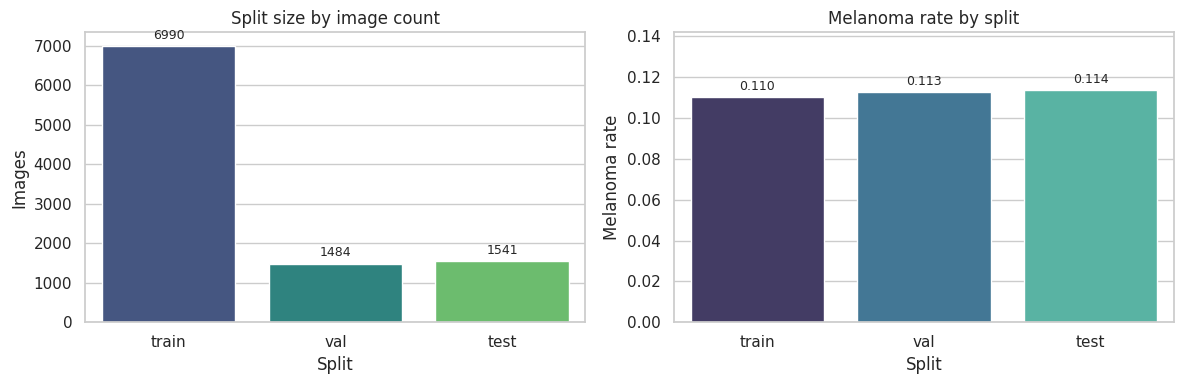

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=split_summary, x='split', y='images', hue='split', dodge=False, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Split size by image count')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Images')

sns.barplot(data=split_summary, x='split', y='melanoma_rate', hue='split', dodge=False, palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Melanoma rate by split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Melanoma rate')
axes[1].set_ylim(0, max(split_summary['melanoma_rate']) * 1.25)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f' if ax is axes[1] else '%d', padding=3, fontsize=9)

fig.tight_layout()
split_plot_path = figure_dir / 'ham10000_split_summary.png'
fig.savefig(split_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved split summary plot to {split_plot_path}')
split_summary